<a href="https://colab.research.google.com/github/rm571222/dataholics-oracle-challenge/blob/main/notebooks/01_data_exploration/nb1_data_exploration_pysus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB1 — Data Exploration: SIH/DATASUS (Internações Hospitalares)

**Projeto DATAHOLICS — FIAP Challenge | Parceria Oracle**

Este notebook documenta a fase de **exploração de dados (EDA)** da fonte primária de internações hospitalares — o SIH/SUS, acessado via biblioteca `pysus`. Esta é a primeira etapa do projeto e o objetivo aqui é entender a fonte, tratar problemas de qualidade e decidir o que será modelado na próxima fase (projeto físico relacional).

## Fonte de dados

- **Sistema:** SIH/SUS (Sistema de Informações Hospitalares do SUS)
- **Arquivo:** RD (AIH Reduzida) — uma linha por internação hospitalar
- **Acesso:** biblioteca `pysus` (Python), que baixa os arquivos oficiais do FTP do DATASUS já convertidos para parquet
- **Recorte:** Estado de São Paulo, competências de junho/2024 a junho/2026

## Estrutura deste notebook

1. Exploração inicial dos dados brutos
2. Seleção das principais variáveis + exploração/qualidade de cada uma
3. Identificação de variáveis que vêm como código, sem descrição
4. Fontes externas encontradas para decodificar essas variáveis
5. Cruzamento de validação entre a fonte externa e o pysus

## 1. Exploração inicial dos dados brutos

Começamos baixando uma amostra representativa (6 meses) e olhando a estrutura crua: quantas colunas existem, que tipo de dado o pandas infere para cada uma, e como são os primeiros registros.

In [ ]:
!pip install -q pysus

from pysus import sih
import pandas as pd
import matplotlib.pyplot as plt

MESES_AMOSTRA = [(2026, m) for m in range(1, 7)]  # jan a jun/2026

dfs_amostra = []
for ano, mes in MESES_AMOSTRA:
    try:
        caminhos = sih(state="SP", year=ano, month=mes)
        caminhos_rd = [p for p in caminhos if "RDSP" in p.upper()]
        if caminhos_rd:
            dfs_amostra.append(pd.concat([pd.read_parquet(p) for p in caminhos_rd], ignore_index=True))
    except Exception as e:
        print(f'{ano}-{mes:02d} falhou: {e}')

df_sih = pd.concat(dfs_amostra, ignore_index=True)
print(f"Total de registros na amostra: {len(df_sih)}")
print(f"Total de colunas disponíveis: {len(df_sih.columns)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.4/351.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0

/tmp/ipykernel_2758/968020579.py:12: PySUSWarning: pysus.sih() is deprecated and will be removed. Use the origin-namespaced API instead, e.g. pysus.ftp.sih(...), pysus.dadosgov.sih(...), or pysus.saude.sih(...). Behavior is unchanged.
  caminhos = sih(state="SP", year=ano, month=mes)
RJSP2601.parquet: 0.00B [00:00, ?B/s]

RDSP2601.parquet: 0.00B [00:00, ?B/s]


ERSP2601.parquet: 0.00B [00:00, ?B/s]


ERSP2601.parquet:   0%|          | 0.00/296k [00:00<?, ?B/s]


ERSP2601.parquet:  22%|██▏       | 65.5k/296k [00:00<00:00, 13.3MB/s]
RJSP2601.parquet:   0%|          | 0.00/676k [00:00<?, ?B/s]
RJSP2601.parquet:  10%|▉         | 65.5k/676k [00:00<00:00, 23.3MB/s]

RDSP2601.parquet:   0%|          | 0.00/13.9M [00:00<?, ?B/s]

RDSP2601.parquet:   0%|          | 65.5k/13.9M [00:00<00:01, 11.6MB/s]


ERSP2601.parquet:  44%|████▍     | 131k/296k [00:00<00:00, 1.44MB/s] 

RDSP2601.parquet:   1%|          | 131k/13.9M [00:00<00:09, 1.44MB/s] 
RJSP2601.parquet:  19%|█▉        | 131k/676k [00:00<0

Total de registros na amostra: 1481162
Total de colunas disponíveis: 114


In [ ]:
df_sih.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1481162 entries, 0 to 1481161
Columns: 114 entries, UF_ZI to FONTE_ORC
dtypes: object(114)
memory usage: 1.3+ GB


In [ ]:
# Apresentação de todas as colunas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df_sih.head()

,UF_ZI,ANO_CMPT,MES_CMPT,ESPEC,CGC_HOSP,N_AIH,IDENT,CEP,MUNIC_RES,NASC,SEXO,UTI_MES_IN,UTI_MES_AN,UTI_MES_AL,UTI_MES_TO,MARCA_UTI,UTI_INT_IN,UTI_INT_AN,UTI_INT_AL,UTI_INT_TO,DIAR_ACOM,QT_DIARIAS,PROC_SOLIC,PROC_REA,VAL_SH,VAL_SP,VAL_SADT,VAL_RN,VAL_ACOMP,VAL_ORTP,VAL_SANGUE,VAL_SADTSR,VAL_TRANSP,VAL_OBSANG,VAL_PED1AC,VAL_TOT,VAL_UTI,US_TOT,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,COBRANCA,NATUREZA,NAT_JUR,GESTAO,RUBRICA,IND_VDRL,MUNIC_MOV,COD_IDADE,IDADE,DIAS_PERM,MORTE,NACIONAL,NUM_PROC,CAR_INT,TOT_PT_SP,CPF_AUT,HOMONIMO,NUM_FILHOS,INSTRU,CID_NOTIF,CONTRACEP1,CONTRACEP2,GESTRISCO,INSC_PN,SEQ_AIH5,CBOR,CNAER,VINCPREV,GESTOR_COD,GESTOR_TP,GESTOR_CPF,GESTOR_DT,CNES,CNPJ_MANT,INFEHOSP,CID_ASSO,CID_MORTE,COMPLEX,FINANC,FAEC_TP,REGCT,RACA_COR,ETNIA,SEQUENCIA,REMESSA,AUD_JUST,SIS_JUST,VAL_SH_FED,VAL_SP_FED,VAL_SH_GES,VAL_SP_GES,VAL_UCI,MARCA_UCI,DIAGSEC1,DIAGSEC2,DIAGSEC3,DIAGSEC4,DIAGSEC5,DIAGSEC6,DIAGSEC7,DIAGSEC8,DIAGSEC9,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9,FONTE_ORC
0,350000,2026,01,04,62220637000302,3510122257752,5,07082050,351880,19991018,1,0,0,0,0,00,0,0,0,0,0,31,0303130059,0303130059,2015.62,173.29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2188.91,0.00,425.85,20100930,20260131,G09,0000,21,00,3999,2,0,0,351880,4,26,31,0,010,,01,0,,0,0,0,,00,00,1,000000000000,000,000000,000,0,00000,0,000000000000000,,2082276,,,0000,0000,02,06,,0000,03,0000,79219,HE35000001N202601.DTS,,,0.00,0.00,0.00,0.00,0.00,00,F710,,,,,,,,,1,0,0,0,0,0,0,0,0,00
1,350000,2026,01,04,62220637000302,3510123677214,5,07082050,351880,19530629,3,0,0,0,0,00,0,0,0,0,0,31,0303130059,0303130059,2015.62,173.29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2188.91,0.00,425.85,20101107,20260131,G821,0000,21,00,3999,2,0,0,351880,4,72,31,0,010,,01,0,,0,0,0,,00,00,1,000000000000,000,000000,000,0,00000,0,000000000000000,,2082276,,,0000,0000,02,06,,0000,03,0000,79220,HE35000001N202601.DTS,,,0.00,0.00,0.00,0.00,0.00,00,F721,,,,,,,,,1,0,0,0,0,0,0,0,0,00
2,350000,2026,01,04,62220637000302,3510125471512,5,07082050,351880,19840113,1,0,0,0,0,00,0,0,0,0,0,31,0303130059,0303130059,2015.62,173.29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2188.91,0.00,425.85,20101214,20260131,G800,0000,21,00,3999,2,0,0,351880,4,41,31,0,010,,01,0,,0,0,0,,00,00,1,000000000000,000,000000,000,0,00000,0,000000000000000,,2082276,,,0000,0000,02,06,,0000,01,0000,79221,HE35000001N202601.DTS,,,0.00,0.00,0.00,0.00,0.00,00,F720,,,,,,,,,1,0,0,0,0,0,0,0,0,00
3,350000,2026,01,04,62220637000302,3510125471534,5,07082050,351880,19770103,3,0,0,0,0,00,0,0,0,0,0,31,0303130059,0303130059,2015.62,173.29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2188.91,0.00,425.85,20101205,20260131,G821,0000,21,00,3999,2,0,0,351880,4,48,31,0,010,,01,0,,0,0,0,,00,00,1,000000000000,000,000000,000,0,00000,0,000000000000000,,2082276,,,0000,0000,02,06,,0000,01,0000,79222,HE35000001N202601.DTS,,,0.00,0.00,0.00,0.00,0.00,00,F731,,,,,,,,,1,0,0,0,0,0,0,0,0,00
4,350000,2026,01,04,62220637000302,3510125471578,5,07082050,351880,20040331,3,0,0,0,0,00,0,0,0,0,0,31,0303130059,0303130059,2015.62,173.29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2188.91,0.00,425.85,20101210,20260131,G800,0000,21,00,3999,2,0,0,351880,4,21,31,0,010,,01,0,,0,0,0,,00,00,1,000000000000,000,000000,000,0,00000,0,000000000000000,,2082276,,,0000,0000,02,06,,0000,03,0000,79223,HE35000001N202601.DTS,,,0.00,0.00,0.00,0.00,0.00,00,F721,,,,,,,,,1,0,0,0,0,0,0,0,0,00


Aqui identificamos que várias colunas estão no formato de código, sendo necessária a tradução desses dados através de fontes externas - feito posteriormente, após a seleção das principais variáveis

In [ ]:
# Resumo das variáveis
resumo_vars = pd.DataFrame({
    'tipo': df_sih.dtypes,
    'n_nulos': df_sih.isnull().sum(),
    '%_nulos': (df_sih.isnull().mean() * 100).round(2),
    'n_unicos': df_sih.nunique()
}).sort_values('%_nulos', ascending=False)

resumo_vars

,tipo,n_nulos,%_nulos,n_unicos
UF_ZI,object,0,0.0,289
ANO_CMPT,object,0,0.0,1
MES_CMPT,object,0,0.0,6
ESPEC,object,0,0.0,14
CGC_HOSP,object,0,0.0,503
...,...,...,...,...
TPDISEC6,object,0,0.0,3
TPDISEC7,object,0,0.0,3
TPDISEC8,object,0,0.0,3
TPDISEC9,object,0,0.0,3


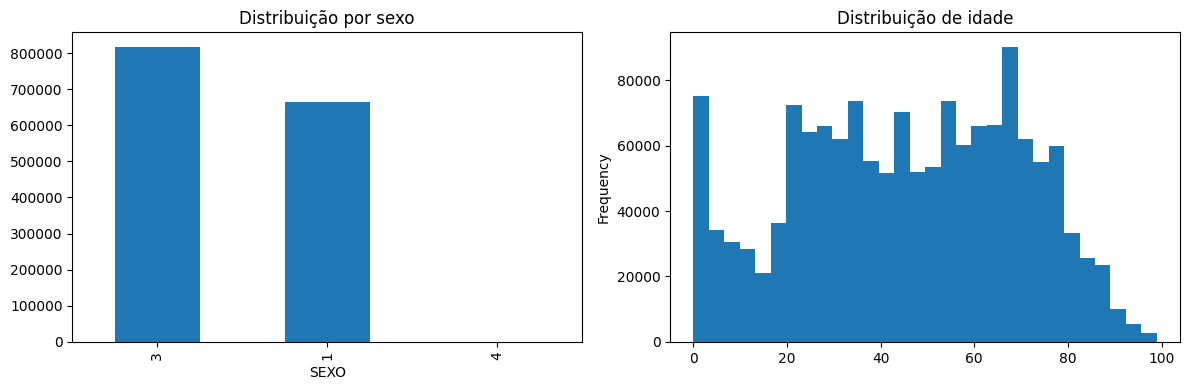

In [ ]:
# Distribuição por sexo e por idade dos pacientes internados
colunas_numericas = ['IDADE', 'DIAS_PERM', 'VAL_TOT', 'UTI_MES_TO', 'VAL_SH', 'VAL_SP', 'QT_DIARIAS']
colunas_numericas = [c for c in colunas_numericas if c in df_sih.columns]
for col in colunas_numericas:
    df_sih[col] = pd.to_numeric(df_sih[col], errors='coerce')  # erros viram NaN em vez de quebrar

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_sih['SEXO'].value_counts().plot(
    kind='bar', ax=axes[0], title='Distribuição por sexo'
)

df_sih['IDADE'].plot(
    kind='hist', bins=30, ax=axes[1], title='Distribuição de idade'
)

plt.tight_layout()
plt.show()

In [ ]:
# Classifica o procedimento em baixa/média/alta complexidade
df_sih['COMPLEX'].value_counts(normalize=True).mul(100).round(1)

,proportion
COMPLEX,
02,89.7
03,10.3


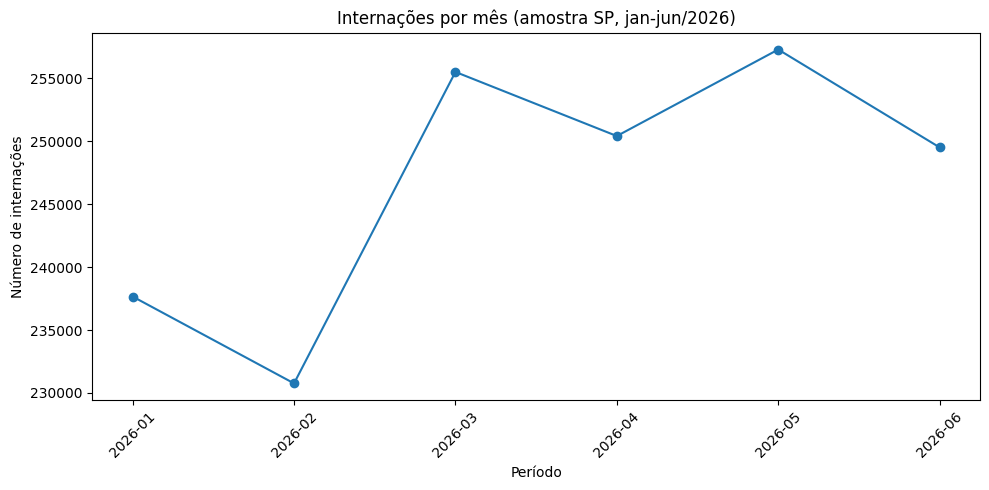

In [ ]:
# Evolução mensal

if 'MES_CMPT' in df_sih.columns and 'ANO_CMPT' in df_sih.columns:
    contagem_mes = df_sih.groupby(['ANO_CMPT', 'MES_CMPT']).size().reset_index(name='n_internacoes')
    contagem_mes['periodo'] = contagem_mes['ANO_CMPT'].astype(str) + '-' + contagem_mes['MES_CMPT'].astype(str).str.zfill(2)

    plt.figure(figsize=(10, 5))
    plt.plot(contagem_mes['periodo'], contagem_mes['n_internacoes'], marker='o')
    plt.title('Internações por mês (amostra SP, jan-jun/2026)')
    plt.xlabel('Período')
    plt.ylabel('Número de internações')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Colunas ANO_CMPT/MES_CMPT não encontradas — confira os nomes reais com df_sih.columns")

## 2. Seleção das principais variáveis e + exploração com foco em qualidade

Combinamos duas informações para decidir o que vale explorar a fundo: a **taxa de preenchimento** (quanto da coluna tem valor de fato, tratando zero/vazio como não-informativo quando aplicável) e a **relevância para as perguntas de negócio do projeto** (volume de internações por região, causas em expansão, cruzamento com capacidade hospitalar).

In [ ]:
def resumo_coluna(serie):
    vazio = serie.isna() | (serie.astype(str).str.strip().isin(['', '0', '00', '000', 'nan', 'None']))
    return pd.Series({
        'pct_preenchido': round((1 - vazio.mean()) * 100, 1),
        'valores_distintos': serie.nunique(),
        'exemplo': serie.dropna().iloc[0] if serie.notna().any() else None
    })

resumo_geral = df_sih.apply(resumo_coluna).T.sort_values('pct_preenchido', ascending=False)
pd.set_option('display.max_rows', 120)
resumo_geral

,pct_preenchido,valores_distintos,exemplo
UF_ZI,100.0,289,350000
GESTAO,100.0,2,2
CBOR,100.0,11,000000
INSC_PN,100.0,26048,000000000000
ANO_CMPT,100.0,1,2026
CAR_INT,100.0,6,01
NACIONAL,100.0,160,010
COD_IDADE,100.0,4,4
NAT_JUR,100.0,16,3999
VAL_TOT,100.0,328590.0,2188.91


### Nota metodológica sobre a métrica de preenchimento

A função acima trata `0` como "vazio" — uma aproximação prática que gera viés em colunas onde `0` é um valor **válido e informativo**, não ausência de dado. Os casos mais relevantes: `MORTE` (0 = não houve óbito, por isso aparece com preenchimento baixo mesmo sendo um indicador correto) e `UTI_MES_TO` (0 = não usou UTI). Essas colunas não têm problema de qualidade — têm distribuição naturalmente concentrada em zero.

### Seleção final — as 21 variáveis escolhidas para o modelo físico

Com base na exploração acima e nas perguntas de negócio do projeto, selecionamos as seguintes colunas para compor a futura tabela fato de internações:

`ANO_CMPT`, `MES_CMPT`, `ESPEC`, `N_AIH`, `IDENT`, `CNES`, `MUNIC_MOV`, `SEXO`, `IDADE`, `MUNIC_RES`, `RACA_COR`, `DIAG_PRINC`, `DT_INTER`, `DT_SAIDA`, `DIAS_PERM`, `MORTE`, `CAR_INT`, `UTI_MES_TO`, `VAL_UTI`, `VAL_TOT`, `COMPLEX`

Fazemos agora um data quality dedicado a essas 21 colunas.

In [ ]:
COLUNAS_SELECIONADAS = ['ANO_CMPT', 'MES_CMPT', 'ESPEC', 'N_AIH', 'IDENT', 'CNES', 'MUNIC_MOV',
                         'SEXO', 'IDADE', 'MUNIC_RES', 'RACA_COR', 'DIAG_PRINC',
                         'DT_INTER', 'DT_SAIDA', 'DIAS_PERM', 'MORTE', 'CAR_INT', 'UTI_MES_TO',
                         'VAL_UTI', 'VAL_TOT', 'COMPLEX']

df_dq = df_sih[COLUNAS_SELECIONADAS].copy()

df_dq['DT_INTER_conv'] = pd.to_datetime(df_dq['DT_INTER'], format='%Y%m%d', errors='coerce')
df_dq['DT_SAIDA_conv'] = pd.to_datetime(df_dq['DT_SAIDA'], format='%Y%m%d', errors='coerce')
for col in ['IDADE', 'DIAS_PERM', 'MORTE', 'UTI_MES_TO', 'VAL_UTI', 'VAL_TOT', 'ANO_CMPT', 'MES_CMPT']:
    df_dq[col + '_num'] = pd.to_numeric(df_dq[col], errors='coerce')

resumo_selecionadas = pd.DataFrame({
    'dtype': df_dq[COLUNAS_SELECIONADAS].dtypes,
    'qtd_nulos': df_dq[COLUNAS_SELECIONADAS].isna().sum(),
    'valores_distintos': df_dq[COLUNAS_SELECIONADAS].nunique()
})
resumo_selecionadas

,dtype,qtd_nulos,valores_distintos
ANO_CMPT,object,0,1
MES_CMPT,object,0,6
ESPEC,object,0,14
N_AIH,object,0,1459714
IDENT,object,0,2
CNES,object,0,626
MUNIC_MOV,object,0,323
SEXO,object,0,3
IDADE,int64,0,100
MUNIC_RES,object,0,2290


In [ ]:
# Domínio de valores esperado para as colunas categóricas
dominios_esperados = {
    'SEXO': {'0', '1', '3'},
    'IDENT': {'1', '5'},
    'RACA_COR': {'01', '02', '03', '04', '05', '99'},
    'MORTE': {'0', '1'},
    'CAR_INT': {'01', '02', '03', '04', '05', '06'},
    'COMPLEX': {'01', '02', '03'},
}

for col, dominio_valido in dominios_esperados.items():
    valores_reais = set(df_dq[col].astype(str).str.strip().unique())
    inesperados = valores_reais - dominio_valido
    print(f"{col}: valores encontrados {sorted(valores_reais)}", "⚠️ fora do domínio: " + str(sorted(inesperados)) if inesperados else "✅")

SEXO: valores encontrados ['1', '3', '4'] ⚠️ fora do domínio: ['4']
IDENT: valores encontrados ['1', '5'] ✅
RACA_COR: valores encontrados ['01', '02', '03', '04', '05', '99'] ✅
MORTE: valores encontrados ['0', '1'] ✅
CAR_INT: valores encontrados ['01', '02', '03', '04', '05', '06'] ✅
COMPLEX: valores encontrados ['02', '03'] ✅


In [ ]:
# Consistência entre colunas
inconsistente_datas = df_dq[df_dq['DT_SAIDA_conv'] < df_dq['DT_INTER_conv']]
print(f"DT_SAIDA < DT_INTER: {len(inconsistente_datas)} linhas")

df_dq['dias_calculados'] = (df_dq['DT_SAIDA_conv'] - df_dq['DT_INTER_conv']).dt.days
divergencia_dias = df_dq[(df_dq['DIAS_PERM_num'] - df_dq['dias_calculados']).abs() > 1]
print(f"DIAS_PERM divergente da diferença de datas (tolerância 1 dia): {len(divergencia_dias)} ({len(divergencia_dias)/len(df_dq)*100:.2f}%)")

val_inconsistente = df_dq[df_dq['VAL_UTI_num'] > df_dq['VAL_TOT_num']]
print(f"VAL_UTI > VAL_TOT: {len(val_inconsistente)} linhas")

uti_sem_custo = df_dq[(df_dq['UTI_MES_TO_num'] > 0) & (df_dq['VAL_UTI_num'] == 0)]
print(f"UTI_MES_TO > 0 mas VAL_UTI = 0: {len(uti_sem_custo)} ({len(uti_sem_custo)/len(df_dq)*100:.2f}%)")

print(f"\nIDADE > 120: {(df_dq['IDADE_num'] > 120).sum()}")
print(f"IDADE negativa: {(df_dq['IDADE_num'] < 0).sum()}")
print(f"VAL_TOT <= 0: {(df_dq['VAL_TOT_num'] <= 0).sum()} ({(df_dq['VAL_TOT_num'] <= 0).mean()*100:.2f}%)")
print(f"VAL_TOT > 500.000: {(df_dq['VAL_TOT_num'] > 500000).sum()}")
print(f"DIAS_PERM > 365: {(df_dq['DIAS_PERM_num'] > 365).sum()}")

duplicatas_mesmo_mes = df_dq.groupby(['ANO_CMPT', 'MES_CMPT'])['N_AIH'].apply(lambda x: x.duplicated().sum()).sum()
print(f"\nN_AIH duplicado dentro da mesma competência: {duplicatas_mesmo_mes}")

DT_SAIDA < DT_INTER: 0 linhas
DIAS_PERM divergente da diferença de datas (tolerância 1 dia): 25248 (1.70%)
VAL_UTI > VAL_TOT: 0 linhas
UTI_MES_TO > 0 mas VAL_UTI = 0: 0 (0.00%)

IDADE > 120: 0
IDADE negativa: 0
VAL_TOT <= 0: 2351 (0.16%)
VAL_TOT > 500.000: 1
DIAS_PERM > 365: 0

N_AIH duplicado dentro da mesma competência: 314


## 3. Variáveis que vêm como código, sem descrição

Das 21 variáveis selecionadas, várias trazem apenas um **código**, sem texto explicativo — o que dificulta qualquer leitura de negócio direta. São elas:

| Coluna | Tipo de código |
|---|---|
| `IDENT`, `SEXO`, `RACA_COR`, `CAR_INT`, `COMPLEX` | Enums pequenos (2 a 6 valores) |
| `DIAG_PRINC` | CID-10 (milhares de códigos possíveis) |
| `MUNIC_MOV`, `MUNIC_RES` | Código IBGE de município (sem nome nem região) |

As duas últimas linhas motivaram a busca de fontes externas — sem elas, não seria possível responder às perguntas de negócio do projeto (que exigem causa da internação em linguagem legível, e visão regional, não só município isolado).

## 4. Fontes externas encontradas

| Necessidade | Fonte | URL |
|---|---|---|
| Descrição CID-10 (`DIAG_PRINC`) | DATASUS/CBCD, tabela oficial de categorias | https://raw.githubusercontent.com/cleytonferrari/CidDataSus/master/CIDImport/Repositorio/Resources/CID-10-CATEGORIAS.CSV |
| Descrição dos enums (`SEXO`, `IDENT`, `CAR_INT`, `RACA_COR`, `COMPLEX`) | Dicionário de dados do CEM/USP + confirmação cruzada DATASUS/SIAB | https://centrodametropole.fflch.usp.br/en/file/16341/download |
| Nome e região de saúde do município (`MUNIC_MOV`, `MUNIC_RES`) | Ministério da Saúde — Regionalização no SUS | https://infoms.saude.gov.br/extensions/SEIDIGI_DEMAS_MACRORREGIOES/SEIDIGI_DEMAS_MACRORREGIOES.html (download manual — portal bloqueia acesso automatizado) |

Nenhuma dessas fontes está disponível dentro do próprio arquivo do SIH — todas exigiram busca e validação externas.

In [ ]:
import requests, io

resp = requests.get("https://raw.githubusercontent.com/cleytonferrari/CidDataSus/master/CIDImport/Repositorio/Resources/CID-10-SUBCATEGORIAS.CSV")
df_cid10 = pd.read_csv(io.BytesIO(resp.content), sep=';', encoding='latin1')
df_cid10 = df_cid10[['SUBCAT', 'DESCRICAO']].rename(columns={'SUBCAT': 'cd_diagnostico', 'DESCRICAO': 'ds_diagnostico'})
df_cid10['cd_diagnostico'] = df_cid10['cd_diagnostico'].astype(str).str.strip()

print(f"Total de subcategorias CID-10 carregadas: {len(df_cid10)}")
df_cid10.head()

/usr/local/lib/python3.13/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.6.0)/charset_normalizer (3.4.9) doesn't match a supported version!
  warnings.warn(


Total de subcategorias CID-10 carregadas: 12451


,cd_diagnostico,ds_diagnostico
0,A000,"Cólera devida a Vibrio cholerae 01, biótipo ch..."
1,A001,"Cólera devida a Vibrio cholerae 01, biótipo El..."
2,A009,Cólera não especificada
3,A010,Febre tifóide
4,A011,Febre paratifóide A


In [ ]:
dominios_dados = {
    'IDENT': {'1': 'AIH Normal', '5': 'AIH de Longa Permanência / FPT'},
    'SEXO': {'0': 'Não informado', '1': 'Masculino', '3': 'Feminino'},
    'RACA_COR': {'01': 'Branca', '02': 'Preta', '03': 'Parda', '04': 'Amarela', '05': 'Indígena', '99': 'Sem informação'},
    'CAR_INT': {
        '01': 'Eletivo', '02': 'Urgência',
        '03': 'Acidente no local de trabalho ou a serviço da empresa',
        '04': 'Acidente no trajeto para o trabalho',
        '05': 'Outros tipos de acidente de trânsito',
        '06': 'Outros tipos de lesões e envenenamentos por agentes químicos ou físicos'
    },
    'COMPLEX': {'01': 'Atenção Básica', '02': 'Média Complexidade', '03': 'Alta Complexidade'}
}
for dominio, valores in dominios_dados.items():
    print(f"{dominio}: {valores}")

IDENT: {'1': 'AIH Normal', '5': 'AIH de Longa Permanência / FPT'}
SEXO: {'0': 'Não informado', '1': 'Masculino', '3': 'Feminino'}
RACA_COR: {'01': 'Branca', '02': 'Preta', '03': 'Parda', '04': 'Amarela', '05': 'Indígena', '99': 'Sem informação'}
CAR_INT: {'01': 'Eletivo', '02': 'Urgência', '03': 'Acidente no local de trabalho ou a serviço da empresa', '04': 'Acidente no trajeto para o trabalho', '05': 'Outros tipos de acidente de trânsito', '06': 'Outros tipos de lesões e envenenamentos por agentes químicos ou físicos'}
COMPLEX: {'01': 'Atenção Básica', '02': 'Média Complexidade', '03': 'Alta Complexidade'}


### Com isso, conseguimos mapear e esclarecer as inconsistências encontradas

| Achado | Tratamento decidido |
|---|---|
| `SEXO = '4'` (10 registros, fora do domínio 0/1/3) | Investigado sem explicação documentada — **tratar** esses registros por serem residuais e sem base documental |
| `DIAS_PERM` divergente da diferença de datas (~1,7%) | Limitação conhecida e documentada do próprio SIH (retificações de data não sincronizadas) — **manter**, sem correção |
| `MORTE = 1` sem `CID_MORTE` preenchido (~4,75%) | Subnotificação real da fonte (hospitais nem sempre preenchem a causa de óbito) — decidiu-se **não incluir `CID_MORTE`** no modelo físico, já que ficaria com causa de óbito ausente na maioria dos casos de óbito |
| `VAL_TOT <= 0` (~0,16%) | Volume baixo, mantido sem tratamento — provavelmente AIH cancelada/glosada |
| `N_AIH` duplicado entre competências diferentes | **Não é erro** — é o fenômeno de AIH de longa permanência (`IDENT=5`), que gera um novo registro por mês de permanência, mantendo o mesmo número de AIH. Confirmado com literatura acadêmica (ver Seção 5) |
| `N_AIH` duplicado dentro da **mesma** competência (residual, poucas dezenas a centenas por mês) | Duplicidade legítima e documentada na literatura sobre o SIH/SUS — decisão de modelagem: chave primária composta (`N_AIH` + competência) no projeto físico, aceitando a duplicata residual como parte do dado real |

In [ ]:
# Aplicação do único tratamento decidido nesta fase de exploração (tratamento do SEXO fora do domínio para Código 0 - Não informado)
qtd_recodificados = (~df_dq['SEXO'].astype(str).str.strip().isin(['0', '1', '3'])).sum()

df_dq['SEXO'] = df_dq['SEXO'].astype(str).str.strip().where(
    df_dq['SEXO'].astype(str).str.strip().isin(['0', '1', '3']), '0'
)

print(f"Registros recodificados para SEXO='0' (Não informado): {qtd_recodificados}")
print(df_dq['SEXO'].value_counts())

Registros recodificados para SEXO='0' (Não informado): 10
SEXO
3    816724
1    664428
0        10
Name: count, dtype: int64


## 5. Cruzamento de validação entre a fonte externa e o pysus

Antes de considerar essas fontes confiáveis para uso, validamos a **cobertura**: quanto dos valores reais encontrados no SIH tem correspondência na fonte externa.

In [ ]:
codigos_cid10 = set(df_cid10['cd_diagnostico'])

def valida_cid(codigo):
    codigo = str(codigo).strip()
    if codigo in codigos_cid10:
        return 'match_exato'
    elif len(codigo) == 3 and (codigo + '0') in codigos_cid10:
        return 'match_categoria_sem_subdivisao'
    elif codigo[:3] in codigos_cid10:
        return 'match_3_digitos'
    else:
        return 'sem_match'

df_dq['diag_princ_status'] = df_dq['DIAG_PRINC'].apply(valida_cid)
print(df_dq['diag_princ_status'].value_counts())
cobertura_cid = (df_dq['diag_princ_status'] != 'sem_match').mean() * 100
print(f"\nCobertura CID-10: {cobertura_cid:.2f}%")

sem_match = sorted(df_dq[df_dq['diag_princ_status'] == 'sem_match']['DIAG_PRINC'].value_counts().items())
print(f"\nCódigos sem correspondência (residual, {len(sem_match)} códigos únicos):")
print(sem_match)

diag_princ_status
match_exato                       1447282
match_categoria_sem_subdivisao      33680
sem_match                             200
Name: count, dtype: int64

Cobertura CID-10: 99.99%

Códigos sem correspondência (residual, 13 códigos únicos):
[('N182', 8), ('N183', 3), ('N184', 19), ('N185', 80), ('Q35', 3), ('R50', 68), ('S19', 1), ('S49', 2), ('S59', 4), ('S69', 5), ('S79', 3), ('S99', 3), ('U10', 1)]


**Nota sobre o residual sem correspondência (0,01%):** os poucos códigos sem match (`N182-N185`, `Q35`, `S19/S49/S59/S69/S79/S99`, `U10`) concentram-se em códigos criados ou revisados **após 2008** — a versão da tabela CID-10 utilizada. Destaque para `U10` (Síndrome Inflamatória Multissistêmica associada à COVID-19), que é posterior à pandemia. Dado o volume irrisório (0,014% da base), optou-se por manter a versão 2008 da tabela em vez de buscar uma fonte mais recente.

In [ ]:
for coluna, dominio in dominios_esperados.items():
    cobertura = df_dq[coluna].astype(str).str.strip().isin(dominio).mean() * 100
    print(f"{coluna}: {cobertura:.2f}% de cobertura no domínio")

SEXO: 100.00% de cobertura no domínio
IDENT: 100.00% de cobertura no domínio
RACA_COR: 100.00% de cobertura no domínio
MORTE: 100.00% de cobertura no domínio
CAR_INT: 100.00% de cobertura no domínio
COMPLEX: 100.00% de cobertura no domínio


In [ ]:
# Cruzamento com a fonte de Região de Saúde (upload manual do arquivo do Ministério da Saúde)
from google.colab import files
uploaded = files.upload()  # selecione o CSV de região de saúde (Ministério da Saúde)

nome_arquivo = list(uploaded.keys())[0]
df_regiao_raw = pd.read_csv(nome_arquivo)

df_regiao = df_regiao_raw[df_regiao_raw['UF'] == 'Sao Paulo'].copy()
df_regiao = df_regiao.rename(columns={
    'Codigo Municipio': 'cd_municipio',
    'Municipio': 'nm_municipio',
    'Codigo Regiao de Saude': 'cd_regiao_saude',
    'Regiao de Saude': 'nm_regiao_saude',
    'Codigo Macrorregiao de Saude': 'cd_macrorregiao',
    'Macrorregiao de Saude': 'nm_macrorregiao'
})
df_regiao['cd_municipio'] = df_regiao['cd_municipio'].astype(str)

print(f"Municípios de SP carregados: {len(df_regiao)}")
print(f"Regiões de saúde únicas: {df_regiao['cd_regiao_saude'].nunique()}")
print(f"Macrorregiões únicas: {df_regiao['cd_macrorregiao'].nunique()}")

municipios_regiao = set(df_regiao['cd_municipio'])
municipios_sih_hospital = set(df_sih['MUNIC_MOV'].astype(str).str.strip())
municipios_sih_residencia = set(df_sih['MUNIC_RES'].astype(str).str.strip())

sem_regiao_hospital = municipios_sih_hospital - municipios_regiao
sem_regiao_residencia = municipios_sih_residencia - municipios_regiao

print(f"Municípios de HOSPITAL sem correspondência: {len(sem_regiao_hospital)} de {len(municipios_sih_hospital)}")
print(f"Municípios de RESIDÊNCIA sem correspondência: {len(sem_regiao_residencia)} de {len(municipios_sih_residencia)}")

prefixos_uf = pd.Series([c[:2] for c in sem_regiao_residencia]).value_counts()
print(f"\nPrefixos de UF entre os municípios de residência sem correspondência (confirma serem de outros estados):")
print(prefixos_uf.head(10))

Saving base_regiao_ministerio_da_saude.csv to base_regiao_ministerio_da_saude.csv
Municípios de SP carregados: 645
Regiões de saúde únicas: 62
Macrorregiões únicas: 19
Municípios de HOSPITAL sem correspondência: 0 de 323
Municípios de RESIDÊNCIA sem correspondência: 1645 de 2290

Prefixos de UF entre os municípios de residência sem correspondência (confirma serem de outros estados):
31    386
29    164
41    128
52    107
51     92
42     67
15     62
21     61
50     58
23     56
Name: count, dtype: int64


**Conclusão do cruzamento:** cobertura de 100% para município de **hospital** (esperado, já que o projeto é restrito a SP) e cobertura parcial para município de **residência** — o resíduo corresponde a pacientes de outros estados internados em SP, o que é esperado dado o papel de São Paulo como polo de referência em saúde de alta complexidade.

## Dicionário de dados — variáveis selecionadas

| Coluna (DATASUS) | Descrição | Fonte de descrição |
|---|---|---|
| `N_AIH` | Número da Autorização de Internação Hospitalar | — (identificador) |
| `CNES` | Código do estabelecimento (hospital) | Cadastro CNES |
| `MUNIC_MOV` | Município do hospital | Ministério da Saúde (Região de Saúde) |
| `MUNIC_RES` | Município de residência do paciente | Ministério da Saúde (Região de Saúde) |
| `ANO_CMPT` / `MES_CMPT` | Ano/mês de competência (processamento) | — |
| `IDENT` | Tipo de AIH: 1-Normal, 5-Longa permanência/FPT | CEM/USP |
| `SEXO` | 0-Não informado, 1-Masculino, 3-Feminino | CEM/USP |
| `IDADE` | Idade do paciente | — |
| `RACA_COR` | 01-Branca, 02-Preta, 03-Parda, 04-Amarela, 05-Indígena, 99-Sem informação | CEM/USP |
| `DIAG_PRINC` | CID-10 do diagnóstico principal | DATASUS/CBCD |
| `ESPEC` | Especialidade do leito | DATASUS/SIAB |
| `DT_INTER` / `DT_SAIDA` | Datas de internação e saída | — |
| `DIAS_PERM` | Dias de permanência | — |
| `MORTE` | 0-Não, 1-Sim (óbito) | — |
| `CAR_INT` | Caráter da internação (eletivo/urgência/acidente) | CEM/USP |
| `UTI_MES_TO` | Dias de UTI no mês | — |
| `VAL_UTI` | Valor gasto em UTI | — |
| `VAL_TOT` | Valor total da internação | — |
| `COMPLEX` | 01-Atenção Básica, 02-Média, 03-Alta Complexidade | — |

*(Dicionário completo das 114 colunas originais disponível em documento separado: `dicionario_dados_colunas_sih.md`)*

## Conclusão da exploração — NB1

A exploração da fonte SIH/pysus resultou em: (1) seleção de 21 variáveis relevantes das 114 disponíveis, priorizadas pelas perguntas de negócio do projeto; (2) identificação e tratamento de inconsistências pontuais (SEXO fora de domínio, tratado); (3) esclarecimento de padrões que pareciam inconsistência mas são características legítimas da fonte (duplicata de AIH entre competências, subnotificação de causa de óbito); (4) validação cruzada com 3 fontes externas (CID-10: 99,99% de cobertura; domínios de enum: 100%; região de saúde: 100% para hospital). Essas variáveis e fontes formam a base para a modelagem física a ser desenvolvida na próxima etapa do projeto.